<a href="https://colab.research.google.com/github/Mukeshburdak/Prediction-of-Agriculture-Crop-Production-in-India/blob/main/Prediction_of_Agriculture_Crop_Production_in_India_Algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # 1. IMPORTS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,r2_score)

# 2. LOAD DATA

- Dataset 1: Crop Cost & Yield (datafile_1.csv)

In [ ]:
df_cost = pd.read_csv("datafile_1.csv")
df_cost.columns = df_cost.columns.str.strip()

- Dataset 2: Production / Area / Yield Index (datafile_2.csv)

In [ ]:
df_index = pd.read_csv("datafile_2.csv")
df_index.columns = df_index.columns.str.strip()
df_index["Crop"] = df_index["Crop             "].str.strip() \
    if "Crop             " in df_index.columns else df_index.iloc[:, 0].str.strip()

- Dataset 3: Production time-series (produce.csv)

In [ ]:
df_prod = pd.read_csv("produce.csv")

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nCost & Yield Dataset  → {df_cost.shape[0]} rows × {df_cost.shape[1]} cols")
print(df_cost.head(3).to_string())

print(f"\nProduction Index Data → {df_index.shape[0]} rows × {df_index.shape[1]} cols")

print(f"\nProduction Time-Series → {df_prod.shape[0]} rows × {df_prod.shape[1]} cols")

DATASET OVERVIEW

Cost & Yield Dataset  → 49 rows × 6 cols
    Crop          State  Cost of Cultivation (`/Hectare) A2+FL  Cost of Cultivation (`/Hectare) C2  Cost of Production (`/Quintal) C2  Yield (Quintal/ Hectare)
0  ARHAR  Uttar Pradesh                                9794.05                            23076.74                            1941.55                      9.83
1  ARHAR      Karnataka                               10593.15                            16528.68                            2172.46                      7.47
2  ARHAR        Gujarat                               13468.82                            19551.90                            1898.30                      9.59

Production Index Data → 55 rows × 16 cols

Production Time-Series → 429 rows × 25 cols


# 3. DATA CLEANING & PREPROCESSING

# 3A. Cost & Yield Dataset

In [ ]:
df = df_cost.copy()

# Rename columns for convenience

In [ ]:
df.columns = ["Crop", "State", "Cost_A2FL", "Cost_C2","Cost_Production_Quintal", "Yield_Quintal_Hectare"]
print(f"\nMissing values before cleaning:\n{df.isnull().sum()}")
df.dropna(inplace=True)
print(f"Rows after dropping NaN: {len(df)}")


Missing values before cleaning:
Crop                       0
State                      0
Cost_A2FL                  0
Cost_C2                    0
Cost_Production_Quintal    0
Yield_Quintal_Hectare      0
dtype: int64
Rows after dropping NaN: 49


# Encode categorical columns

In [ ]:
le_crop  = LabelEncoder()
le_state = LabelEncoder()
df["Crop_enc"]  = le_crop.fit_transform(df["Crop"])
df["State_enc"] = le_state.fit_transform(df["State"])

print("\nEncoded Crops :", list(le_crop.classes_))
print("Encoded States:", list(le_state.classes_))


Encoded Crops : ['ARHAR', 'COTTON', 'GRAM', 'GROUNDNUT', 'MAIZE', 'MOONG', 'PADDY', 'RAPESEED AND MUSTARD', 'SUGARCANE', 'WHEAT']
Encoded States: ['Andhra Pradesh', 'Bihar', 'Gujarat', 'Haryana', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Orissa', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Uttar Pradesh', 'West Bengal']


# 3B. Features & Target
# Target  : Yield (Quintal/Hectare)  - proxy for production efficiency
# Features: Crop type, State, Cultivation costs, Production cost

In [ ]:
FEATURES = ["Crop_enc", "State_enc", "Cost_A2FL", "Cost_C2",
            "Cost_Production_Quintal"]
TARGET   = "Yield_Quintal_Hectare"

X = df[FEATURES]
y = df[TARGET]

print(f"\nFeature matrix : {X.shape}")
print(f"Target variable: {TARGET}  |  range [{y.min():.2f} – {y.max():.2f}]")


Feature matrix : (49, 5)
Target variable: Yield_Quintal_Hectare  |  range [1.32 – 1015.45]


# 3C. Feature Scaling

In [ ]:
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

#3D. Train / Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"\nTrain samples: {len(X_train)}  |  Test samples: {len(X_test)}")


Train samples: 39  |  Test samples: 10


# 4. HELPER: Evaluation Function

In [ ]:
def evaluate(model, name, X_tr, y_tr, X_te, y_te):
    """Train, predict and print metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)

    # 5-fold cross-validation R²
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_r2 = cross_val_score(model, X_tr, y_tr, cv=cv,scoring="r2").mean()

    print(f"\n{'─'*40}")
    print(f"  Model : {name}")
    print(f"{'─'*40}")
    print(f"  MAE              : {mae:.4f}")
    print(f"  RMSE             : {rmse:.4f}")
    print(f"  R² Score (test)  : {r2:.4f}")
    print(f"  CV R² (5-fold)   : {cv_r2:.4f}")
    return {"Model": name, "MAE": mae, "RMSE": rmse,"R2": r2, "CV_R2": cv_r2, "y_pred": y_pred}

# 5. ALGORITHM 1 - LINEAR REGRESSION (Baseline)

In [ ]:
print("\n" + "=" * 60)
print("MODEL TRAINING & EVALUATION")
print("=" * 60)

lr_model  = LinearRegression()
lr_result = evaluate(lr_model, "Linear Regression", X_train, y_train, X_test, y_test)


MODEL TRAINING & EVALUATION

────────────────────────────────────────
  Model : Linear Regression
────────────────────────────────────────
  MAE              : 116.7596
  RMSE             : 140.9848
  R² Score (test)  : 0.7800
  CV R² (5-fold)   : -23.3003


# 6. ALGORITHM 2 - RANDOM FOREST REGRESSOR

In [ ]:
rf_model  = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=2,
    random_state=42
)
rf_result = evaluate(rf_model, "Random Forest", X_train, y_train, X_test, y_test)


────────────────────────────────────────
  Model : Random Forest
────────────────────────────────────────
  MAE              : 29.2183
  RMSE             : 74.0537
  R² Score (test)  : 0.9393
  CV R² (5-fold)   : 0.5596


# 7. ALGORITHM 3 - GRADIENT BOOSTING REGRESSOR

In [ ]:
gb_model  = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)
gb_result = evaluate(gb_model, "Gradient Boosting",
                     X_train, y_train, X_test, y_test)


────────────────────────────────────────
  Model : Gradient Boosting
────────────────────────────────────────
  MAE              : 25.9721
  RMSE             : 72.0033
  R² Score (test)  : 0.9426
  CV R² (5-fold)   : 0.8620


# 8. COMPARISON TABLE

In [ ]:
print("\n" + "=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)

results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != "y_pred"}
    for r in [lr_result, rf_result, gb_result]
])
print(results_df.to_string(index=False))

best = results_df.loc[results_df["R2"].idxmax(), "Model"]
print(f"\n★  Best Model by R² Score: {best}")


MODEL COMPARISON SUMMARY
            Model        MAE       RMSE       R2      CV_R2
Linear Regression 116.759560 140.984756 0.779973 -23.300270
    Random Forest  29.218292  74.053736 0.939295   0.559615
Gradient Boosting  25.972141  72.003312 0.942610   0.862000

★  Best Model by R² Score: Gradient Boosting


# 9. VISUALIZATIONS

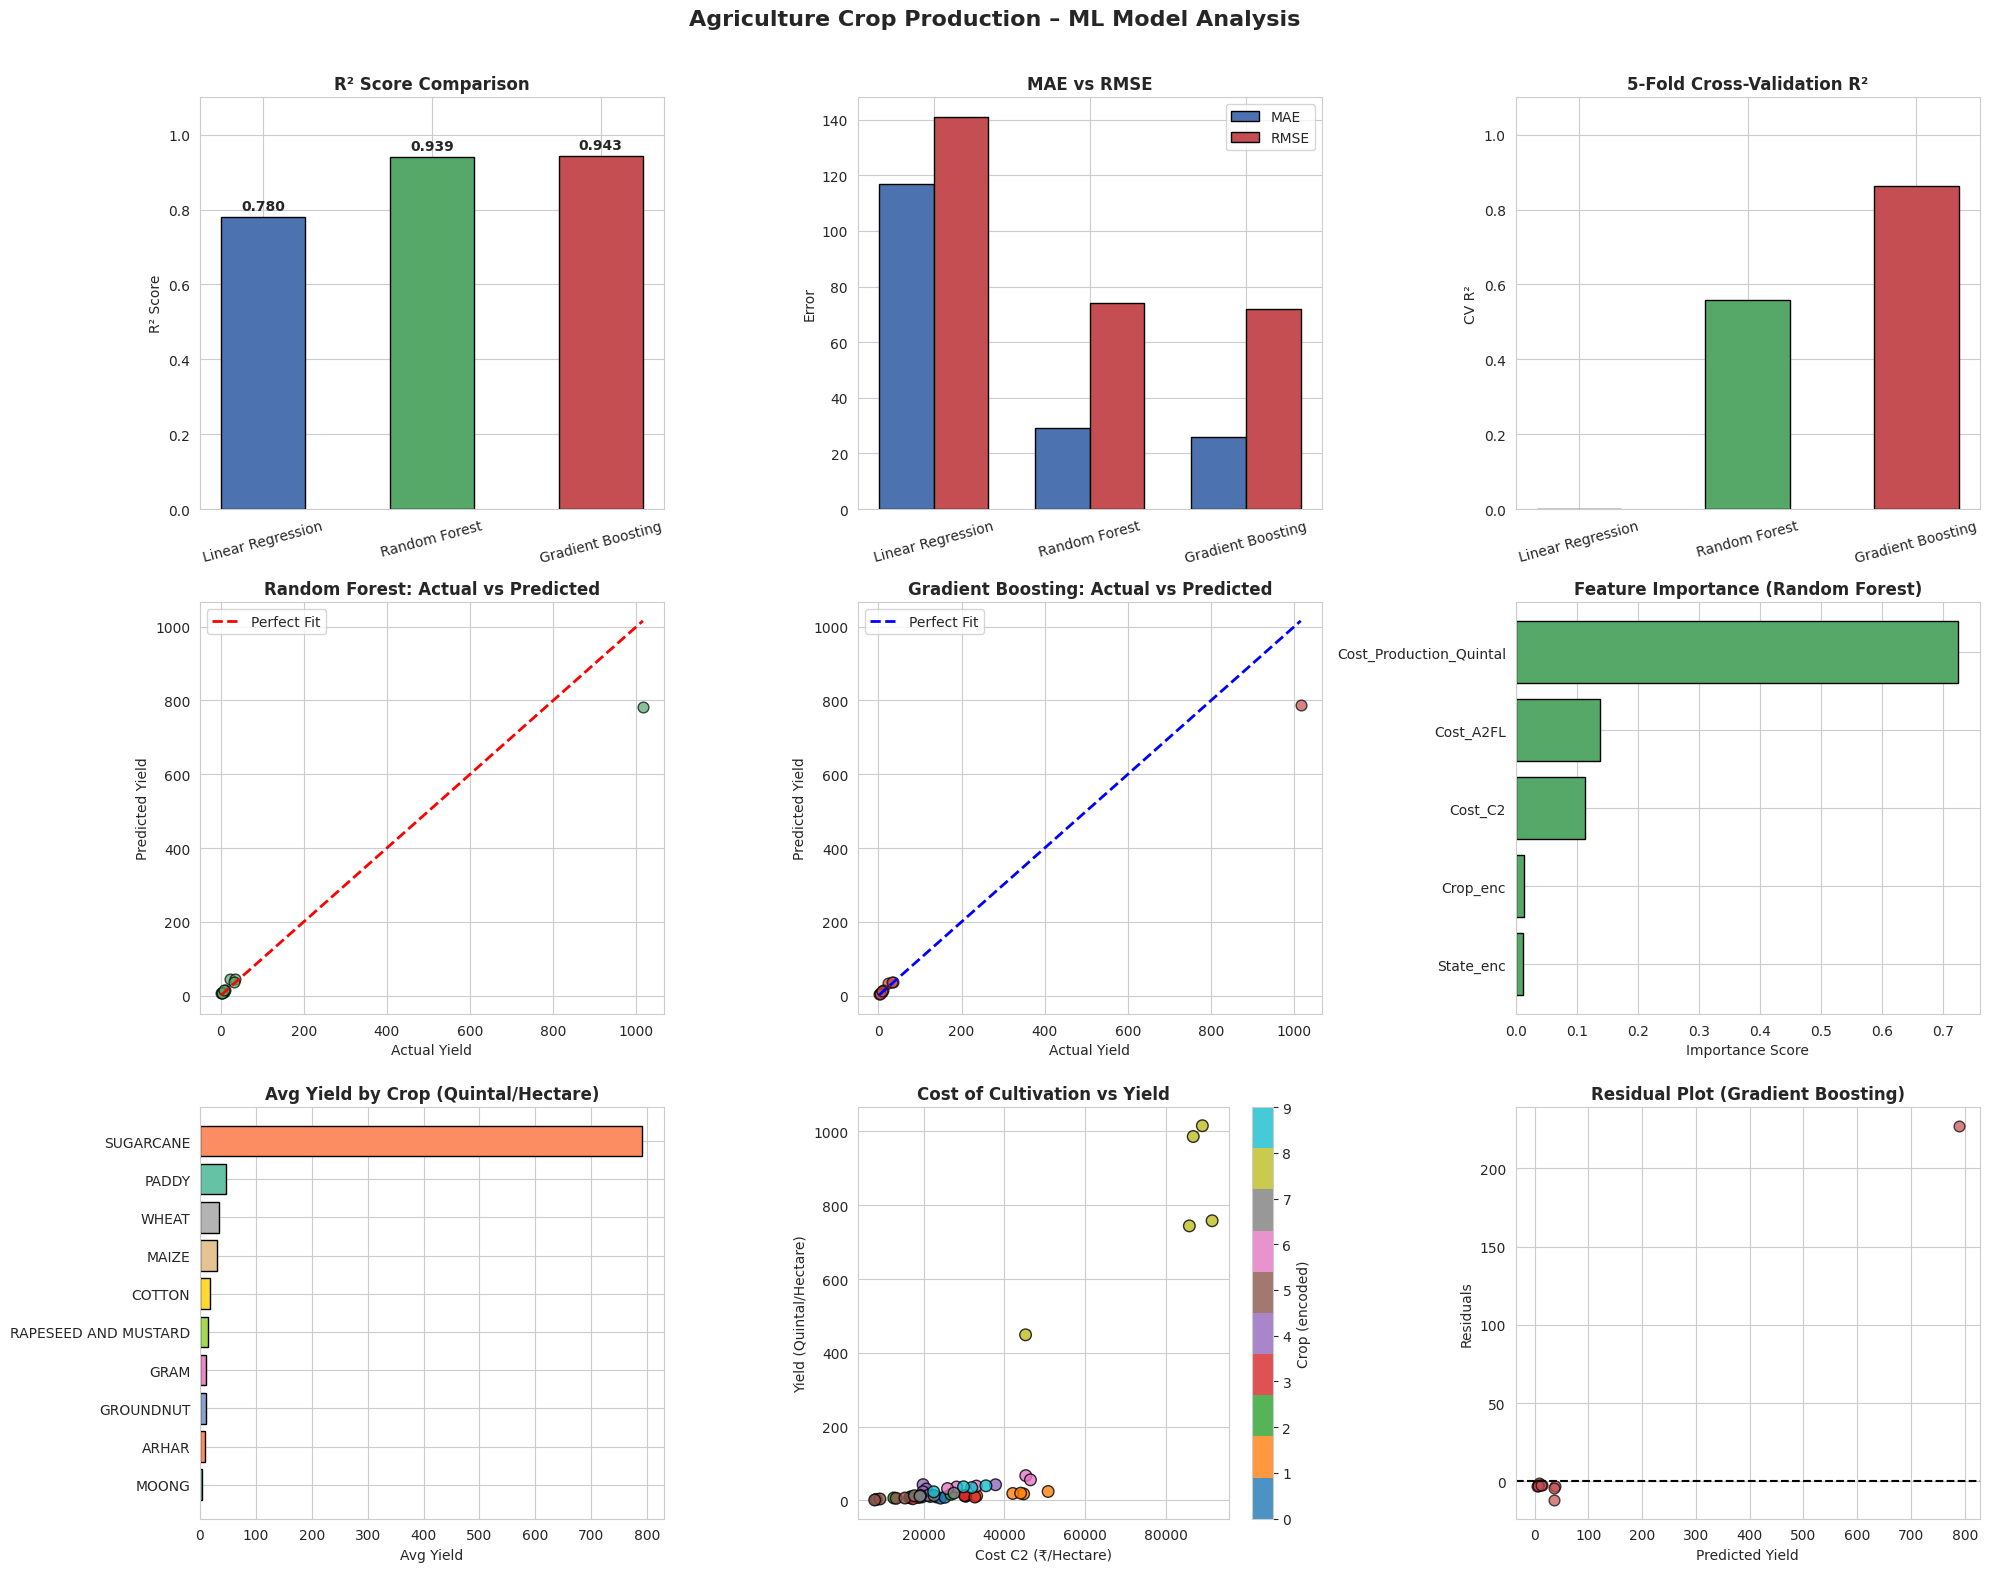


✅  Plot displayed above & saved → agriculture_ml_results.png


In [ ]:
sns.set_style("whitegrid")
fig = plt.figure(figsize=(20, 16))
fig.suptitle("Agriculture Crop Production – ML Model Analysis",
             fontsize=16, fontweight="bold", y=0.98)

# ── Plot 1: R² Comparison ───────────────────
ax1 = fig.add_subplot(3, 3, 1)
models = results_df["Model"].tolist()
r2_vals = results_df["R2"].tolist()
colors = ["#4C72B0", "#55A868", "#C44E52"]
bars = ax1.bar(models, r2_vals, color=colors, edgecolor="black", width=0.5)
ax1.set_title("R² Score Comparison", fontweight="bold")
ax1.set_ylabel("R² Score")
ax1.set_ylim(0, 1.1)
for bar, val in zip(bars, r2_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.02,
             f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")
ax1.tick_params(axis='x', rotation=15)

# ── Plot 2: MAE & RMSE ──────────────────────
ax2 = fig.add_subplot(3, 3, 2)
x = np.arange(len(models))
w = 0.35
ax2.bar(x - w/2, results_df["MAE"],  width=w, label="MAE",
        color="#4C72B0", edgecolor="black")
ax2.bar(x + w/2, results_df["RMSE"], width=w, label="RMSE",
        color="#C44E52", edgecolor="black")
ax2.set_xticks(x); ax2.set_xticklabels(models, rotation=15)
ax2.set_title("MAE vs RMSE", fontweight="bold")
ax2.set_ylabel("Error")
ax2.legend()

# ── Plot 3: CV R² ───────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
ax3.bar(models, results_df["CV_R2"], color=colors, edgecolor="black", width=0.5)
ax3.set_title("5-Fold Cross-Validation R²", fontweight="bold")
ax3.set_ylabel("CV R²")
ax3.set_ylim(0, 1.1)
ax3.tick_params(axis='x', rotation=15)

# ── Plot 4: Actual vs Predicted – RF ────────
ax4 = fig.add_subplot(3, 3, 4)
ax4.scatter(y_test, rf_result["y_pred"], color="#55A868",
            alpha=0.7, edgecolor="k", s=60)
lims = [min(y_test.min(), rf_result["y_pred"].min()),
        max(y_test.max(), rf_result["y_pred"].max())]
ax4.plot(lims, lims, "r--", lw=2, label="Perfect Fit")
ax4.set_title("Random Forest: Actual vs Predicted", fontweight="bold")
ax4.set_xlabel("Actual Yield"); ax4.set_ylabel("Predicted Yield")
ax4.legend()

# ── Plot 5: Actual vs Predicted – GB ────────
ax5 = fig.add_subplot(3, 3, 5)
ax5.scatter(y_test, gb_result["y_pred"], color="#C44E52",
            alpha=0.7, edgecolor="k", s=60)
ax5.plot(lims, lims, "b--", lw=2, label="Perfect Fit")
ax5.set_title("Gradient Boosting: Actual vs Predicted", fontweight="bold")
ax5.set_xlabel("Actual Yield"); ax5.set_ylabel("Predicted Yield")
ax5.legend()

# ── Plot 6: Feature Importance – RF ─────────
ax6 = fig.add_subplot(3, 3, 6)
importances = rf_model.feature_importances_
feat_names  = FEATURES
sorted_idx  = np.argsort(importances)
ax6.barh([feat_names[i] for i in sorted_idx],
         importances[sorted_idx], color="#55A868", edgecolor="black")
ax6.set_title("Feature Importance (Random Forest)", fontweight="bold")
ax6.set_xlabel("Importance Score")

# ── Plot 7: Yield Distribution by Crop ──────
ax7 = fig.add_subplot(3, 3, 7)
crop_yield = df.groupby("Crop")["Yield_Quintal_Hectare"].mean().sort_values()
ax7.barh(crop_yield.index, crop_yield.values,
         color=sns.color_palette("Set2", len(crop_yield)), edgecolor="black")
ax7.set_title("Avg Yield by Crop (Quintal/Hectare)", fontweight="bold")
ax7.set_xlabel("Avg Yield")

# ── Plot 8: Cost vs Yield Scatter ───────────
ax8 = fig.add_subplot(3, 3, 8)
scatter = ax8.scatter(df["Cost_C2"], df["Yield_Quintal_Hectare"],
                      c=df["Crop_enc"], cmap="tab10",
                      alpha=0.8, edgecolor="k", s=70)
ax8.set_title("Cost of Cultivation vs Yield", fontweight="bold")
ax8.set_xlabel("Cost C2 (₹/Hectare)")
ax8.set_ylabel("Yield (Quintal/Hectare)")
plt.colorbar(scatter, ax=ax8, label="Crop (encoded)")

# ── Plot 9: Residual Plot – Best Model ──────
ax9 = fig.add_subplot(3, 3, 9)
best_pred = gb_result["y_pred"]   # Gradient Boosting typically best
residuals = np.array(y_test) - best_pred
ax9.scatter(best_pred, residuals, color="#C44E52",
            alpha=0.7, edgecolor="k", s=60)
ax9.axhline(0, color="black", linestyle="--", lw=1.5)
ax9.set_title("Residual Plot (Gradient Boosting)", fontweight="bold")
ax9.set_xlabel("Predicted Yield")
ax9.set_ylabel("Residuals")

plt.tight_layout(rect=[0, 0, 1, 0.97])

# ── Save to file AND display inline in Jupyter ──
plt.savefig("agriculture_ml_results.png", dpi=150, bbox_inches="tight")
plt.show()          # ← renders the image directly in the notebook cell
plt.close()
print("\n✅  Plot displayed above & saved → agriculture_ml_results.png")

# 10. PREDICTION EXAMPLE

In [ ]:
print("\n" + "=" * 60)
print("SAMPLE PREDICTION (using best model)")
print("=" * 60)

# Example: ARHAR crop in Uttar Pradesh
sample = pd.DataFrame({
    "Crop_enc"               : [le_crop.transform(["ARHAR"])[0]],
    "State_enc"              : [le_state.transform(["Uttar Pradesh"])[0]],
    "Cost_A2FL"              : [9794.05],
    "Cost_C2"                : [23076.74],
    "Cost_Production_Quintal": [1941.55]
})
sample_scaled = scaler.transform(sample)
pred_rf = rf_model.predict(sample_scaled)[0]
pred_gb = gb_model.predict(sample_scaled)[0]

print(f"\n  Crop  : ARHAR  |  State: Uttar Pradesh")
print(f"  Random Forest Prediction  → {pred_rf:.2f} Quintal/Hectare")
print(f"  Gradient Boosting Prediction → {pred_gb:.2f} Quintal/Hectare")
print(f"  Actual Yield (from data)   → 9.83 Quintal/Hectare")

print("\n" + "=" * 60)
print("DONE — All models trained & evaluated successfully!")
print("=" * 60)



SAMPLE PREDICTION (using best model)

  Crop  : ARHAR  |  State: Uttar Pradesh
  Random Forest Prediction  → 9.73 Quintal/Hectare
  Gradient Boosting Prediction → 9.85 Quintal/Hectare
  Actual Yield (from data)   → 9.83 Quintal/Hectare

DONE — All models trained & evaluated successfully!
